## My Question
### ***Write your question here***. What is the average height of a Pokemon and is there a Pokemon that is super tall?

### Study Description
my study is a census because it is taking the height of every single pokemon in the data table.

### Analysis


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("pokemon.csv")
df.head()

,national_number,gen,english_name,japanese_name,primary_type,secondary_type,classification,percent_male,percent_female,height_m,...,evochain_1,evochain_2,evochain_3,evochain_4,evochain_5,evochain_6,gigantamax,mega_evolution,mega_evolution_alt,description
0,1,I,Bulbasaur,Fushigidane,grass,poison,Seed Pokémon,87.5,12.5,0.7,...,Level,Ivysaur,Level,Venusaur,NaN,NaN,NaN,NaN,NaN,There is a plant seed on its back right from t...
1,2,I,Ivysaur,Fushigisou,grass,poison,Seed Pokémon,87.5,12.5,1.0,...,Level,Ivysaur,Level,Venusaur,NaN,NaN,NaN,NaN,NaN,"When the bulb on its back grows large, it appe..."
2,3,I,Venusaur,Fushigibana,grass,poison,Seed Pokémon,87.5,12.5,2.0,...,Level,Ivysaur,Level,Venusaur,NaN,NaN,Gigantamax Venusaur,Mega Venusaur,NaN,Its plant blooms when it is absorbing solar en...
3,4,I,Charmander,Hitokage,fire,NaN,Lizard Pokémon,87.5,12.5,0.6,...,Level,Charmeleon,Level,Charizard,NaN,NaN,NaN,NaN,NaN,It has a preference for hot things. When it ra...
4,5,I,Charmeleon,Lizardo,fire,NaN,Flame Pokémon,87.5,12.5,1.1,...,Level,Charmeleon,Level,Charizard,NaN,NaN,NaN,NaN,NaN,"It has a barbaric nature. In battle, it whips ..."


In [26]:
avg_height = df['height_m'].mean
tallest_pokemon = df.loc[df['height_m'].idxmax()]

bins = [0, 0.5, 1.0, 2.0, 5.0, 10.0, 25.0]
labels = ['Tiny (<0.5m)', 'Small (0.5m-1m)', 'Medium (1m-2m)', 
          'Large (2m-5m)', 'Huge (5m-10m)', 'Super Tall (>10m)']


df['height_bin'] = pd.cut(df['height_m'], bins=bins, labels=labels)


binned_counts = df['height_bin'].value_counts().sort_index()
print(binned_counts)

height_bin
Tiny (<0.5m)         261
Small (0.5m-1m)      294
Medium (1m-2m)       369
Large (2m-5m)         86
Huge (5m-10m)         12
Super Tall (>10m)      3
Name: count, dtype: int64


In [27]:
mean_val = df['height_m'].mean()
std_val = df['height_m'].std()

print(f"Mean: {mean_val:.2f} m")
print(f"Standard Deviation: {std_val:.2f} m")

Mean: 1.21 m
Standard Deviation: 1.25 m


### My Conclusion
1. The average jeight of a pokemon is 1.21m and yes there are some pokemon that are way larger than most and I know this because there haight is greater than the STDx2 + mean.

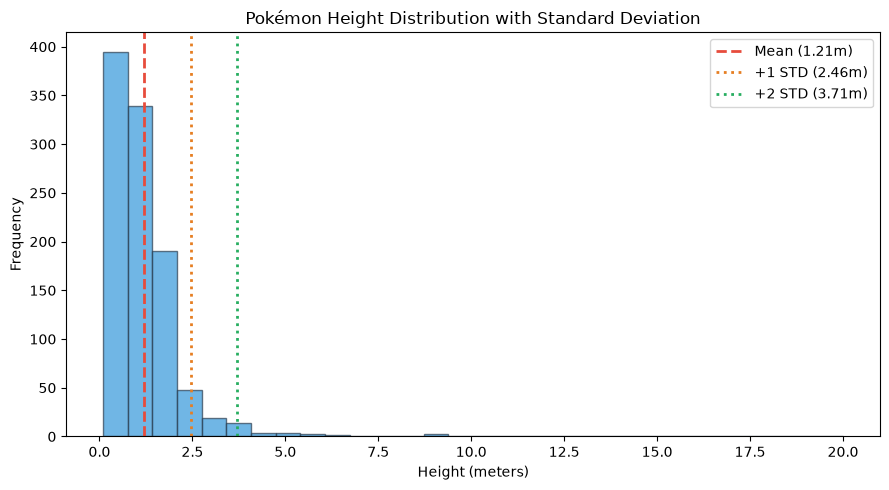

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['height_m'].dropna(), bins=30, color='#3498db', edgecolor='#2c3e50', alpha=0.7)


ax.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean ({mean_val:.2f}m)')
ax.axvline(mean_val + std_val, color='#e67e22', linestyle=':', linewidth=2, label=f'+1 STD ({mean_val + std_val:.2f}m)')
ax.axvline(mean_val + 2*std_val, color='#27ae60', linestyle=':', linewidth=2, label=f'+2 STD ({mean_val + 2*std_val:.2f}m)')

ax.set_xlabel('Height (meters)')
ax.set_ylabel('Frequency')
ax.set_title('Pokémon Height Distribution with Standard Deviation')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Interpret your graph. How does this graph support your answer?
My graph is a major skew right due to the outliers that sit at a very high height. The red line is the mean of the graph, the orange line is std 1 which means if the pokemon is greater than this value they are a larger than suppossed to and the green line is stdx2, which everything right of this line or greater than this l